In [ ]:
import numpy as np

def positional_encoding(pos, d_model):
    def cal_angle(position, i):
        return position / np.power(10000, int(i) / d_model)

    def get_posi_angle_vec(position):
        return [cal_angle(position, i) for i in range(d_model)]

    sinusoid_table = np.array([get_posi_angle_vec(pos_i) for pos_i in range(pos)])

    sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2]) # 짝수 인덱스 
    sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2]) # 홀수 인덱스

    return sinusoid_table

pos = 7
d_model = 4
i = 0

print("Positional Encoding 값:\n", positional_encoding(pos, d_model))

print("")
print("if pos == 0, i == 0: ", np.sin(0 / np.power(10000, 2 * i / d_model)))
print("if pos == 1, i == 0: ", np.sin(1 / np.power(10000, 2 * i / d_model)))
print("if pos == 2, i == 0: ", np.sin(2 / np.power(10000, 2 * i / d_model)))
print("if pos == 3, i == 0: ", np.sin(3 / np.power(10000, 2 * i / d_model)))

print("")
print("if pos == 0, i == 1: ", np.cos(0 / np.power(10000, 2 * i + 1 / d_model)))
print("if pos == 1, i == 1: ", np.cos(1 / np.power(10000, 2 * i + 1 / d_model)))
print("if pos == 2, i == 1: ", np.cos(2 / np.power(10000, 2 * i + 1 / d_model)))
print("if pos == 3, i == 1: ", np.cos(3 / np.power(10000, 2 * i + 1 / d_model)))

Positional Encoding 값:
 [[ 0.          1.          0.          1.        ]
 [ 0.84147098  0.99500417  0.00999983  0.9999995 ]
 [ 0.90929743  0.98006658  0.01999867  0.999998  ]
 [ 0.14112001  0.95533649  0.0299955   0.9999955 ]
 [-0.7568025   0.92106099  0.03998933  0.999992  ]
 [-0.95892427  0.87758256  0.04997917  0.9999875 ]
 [-0.2794155   0.82533561  0.05996401  0.999982  ]]

if pos == 0, i == 0:  0.0
if pos == 1, i == 0:  0.8414709848078965
if pos == 2, i == 0:  0.9092974268256817
if pos == 3, i == 0:  0.1411200080598672

if pos == 0, i == 1:  1.0
if pos == 1, i == 1:  0.9950041652780258
if pos == 2, i == 1:  0.9800665778412416
if pos == 3, i == 1:  0.955336489125606


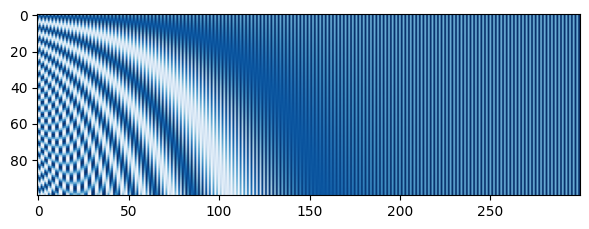

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))
plt.imshow(positional_encoding(100, 300), cmap='Blues')
plt.show()

이 코드는 트랜스포머(Transformer)의 핵심 메커니즘인 **'Scaled Dot-Product Attention'에서 왜 하필 $\sqrt{d_k}$로 나누어주는지(Scaling)** 를 시각적으로 보여주는 실험 코드입니다.

결론부터 말씀드리면, **"차원이 커질수록 점곱(Dot Product) 값이 너무 커져서, 소프트맥스(Softmax)를 취했을 때 한곳으로만 값이 쏠리는 현상을 막으려는 것"** 을 증명하는 코드예요.

torch.Size([30, 30])
torch.Size([30, 30])


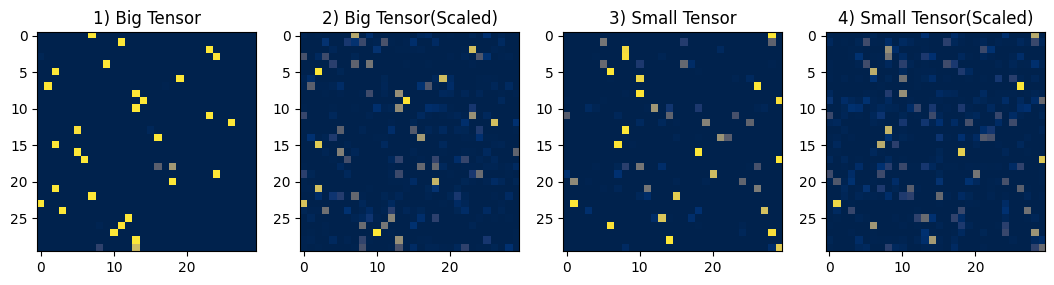

In [ ]:
import torch
import matplotlib.pyplot as plt

def make_dot_product_tensor(shape):
    # torch.rand(shape)
    # 이 함수는 0 이상 1 미만($[0, 1)$) 사이의 숫자를 랜덤하게 생성합니다.
    # 범위: 0 ~ 1

    A = torch.rand(shape) * 6 - 3  # uniform distribution between -3 and 3
    B = (torch.rand(shape) * 6 - 3).transpose(0, 1) #"0번 차원(행)과 1번 차원(열)을 서로 바꿔라"

#tensordot(A, B, dims=n)에서 $n$은 다음을 뜻합니다.

# 첫 번째 텐서(A)의 뒤에서부터 $n$개의 차원과
# 두 번째 텐서(B)의 앞에서부터 $n$개의 차원을
# 서로 대응시켜서 **곱하고 다 더해버려라(Dot Product)**는 뜻입니다.
# 2. 왜 숫자 '1개'인가? (Matrix Multiplication)
# 우리가 중학교, 고등학교 때 배운 일반적인 행렬 곱셈을 생각해 보세요.

# $A$ 행렬: $(30, 1024)$ --- 가로(열) 차원이 1개 있습니다.
# $B$ 행렬: $(1024, 30)$ --- 세로(행) 차원이 1개 있습니다.
# 이 두 행렬을 곱할 때 우리는 A의 가로 한 줄과 B의 세로 한 줄을 짝지어서 계산하죠? 즉, 서로 맞물리는(축약되는) 차원이 딱 1쌍뿐입니다. 그래서 dims=1인 것입니다.
    
    return torch.tensordot(A, B, dims=1)



length = 30
big_dim = 1024.
small_dim = 10.

big_tensor = make_dot_product_tensor((length, int(big_dim)))
print(big_tensor.shape) #(30,30)

# torch.tensor(big_dim) 0차원 스칼라...1024 , torch.sqrt(torch.tensor(big_dim)) $\sqrt{1024}$은 32
# 32로 다 모든 요소나누에서 scaled_big_tensor
scaled_big_tensor = big_tensor / torch.sqrt(torch.tensor(big_dim))
# 전교생이 1024명인 학교의 전교 총점


small_tensor = make_dot_product_tensor((length, int(small_dim)))
# 전교생이 10명인 학교의 전교 총점
print(small_tensor.shape) #(30,30)
scaled_small_tensor = small_tensor / torch.sqrt(torch.tensor(small_dim))

fig = plt.figure(figsize=(13, 6))

ax1 = fig.add_subplot(141)
ax2 = fig.add_subplot(142)
ax3 = fig.add_subplot(143)
ax4 = fig.add_subplot(144)

ax1.set_title('1) Big Tensor')
ax2.set_title('2) Big Tensor(Scaled)')
ax3.set_title('3) Small Tensor')
ax4.set_title('4) Small Tensor(Scaled)')

ax1.imshow(torch.softmax(big_tensor, dim=-1).detach().numpy(), cmap='cividis')
ax2.imshow(torch.softmax(scaled_big_tensor, dim=-1).detach().numpy(), cmap='cividis')
ax3.imshow(torch.softmax(small_tensor, dim=-1).detach().numpy(), cmap='cividis')
ax4.imshow(torch.softmax(scaled_small_tensor, dim=-1).detach().numpy(), cmap='cividis')

plt.show()

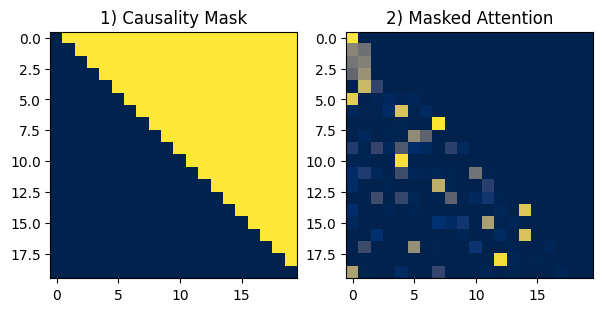

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt

def make_dot_product_tensor(shape):
    A = torch.rand(shape) * 6 - 3  # uniform distribution between -3 and 3
    B = (torch.rand(shape) * 6 - 3).transpose(0, 1)
    
    return torch.tensordot(A, B, dims=1)

def generate_causality_mask(seq_len):
    # np.eye(3, 3) (단위 행렬 생성)
    # [[1. 0. 0.]
    #  [0. 1. 0.]
    #  [0. 0. 1.]]

    # np.cumsum(..., 0) (세로 방향으로 누적 합계)
    # [[1. 0. 0.]
    #  [1. 1. 0.]
    #  [1. 1. 1.]]

    # 1 - ... (반전시키기)
    # [[0. 1. 1.]
    #  [0. 0. 1.]
    #  [0. 0. 0.]]
    
    mask = 1 - np.cumsum(np.eye(seq_len, seq_len), 0)
    return mask

sample_tensor = make_dot_product_tensor((20, 512))
sample_tensor = sample_tensor / torch.sqrt(torch.tensor(512.))
# (20, 20)의 텐서인데, 22.6으로 scaling

mask = generate_causality_mask(sample_tensor.shape[0])
# 20 x 20의 마스크행렬

fig = plt.figure(figsize=(7, 7))

ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

ax1.set_title('1) Causality Mask')
ax2.set_title('2) Masked Attention')

# .detach() 자동미분계산 그래프에서 분리..
ax1.imshow((torch.ones(sample_tensor.shape) + torch.tensor(mask)).detach().numpy(), cmap='cividis')


# 단계: mask *= -1e9 (폭탄 설치)
# 의미: 아까 우리가 만든 마스크 기억하시죠? (과거는 0, 미래는 1)
# 여기에 **-1,000,000,000 (마이너스 10억)**이라는 아주 작은 수를 곱합니다.
# 결과:
# 보여줄 곳(0) 👉 $0 \times (-1e9) = \mathbf{0}$
# 가릴 곳(1) 👉 $1 \times (-1e9) = \mathbf{-1e9}$ (엄청나게 작은 음수)


# 2단계: sample_tensor + torch.tensor(mask) (마스킹 적용)
# 데이터 점수가 들어있는 sample_tensor에 방금 만든 무시무시한 마스크를 더합니다.
# 결과:
# 허용된 데이터 점수 👉 원래 점수 + 0 = 그대로 남음
# 가려야 할 미래 점수 👉 원래 점수 + (-10억) = 약 -10억 (바닥 끝까지 떨어


# 3단계: torch.softmax(..., dim=-1) (확률 변환) 👉 핵심!
# 소프트맥스는 숫자가 클수록 높은 확률을 주고, 작을수록 0에 수렴하는 확률을 줍니다.
# 약 -10억이라는 숫자를 본 소프트맥스는 이렇게 생각합니다.
# "와... 이 점수는 너무 낮아서 확률을 아예 0%라고 봐도 무방하겠네!"

# 결국 미래 단어들은 확률이 0.0000...이 되어 완전히 사라지게 됩니다.
mask *= -1e9
ax2.imshow(torch.softmax(sample_tensor + torch.tensor(mask), dim=-1).detach().numpy(), cmap='cividis')

plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

d_model = 512
warmup_steps = 4000

lrates = []
for step_num in range(1, 50000):
    lrate = (np.power(d_model, -0.5)) * np.min(
        [np.power(step_num, -0.5), step_num * np.power(warmup_steps, -1.5)])
    lrates.append(lrate)

plt.figure(figsize=(6, 3))
plt.plot(lrates)
plt.show()